In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Sample DataFrame
df1 = pd.DataFrame({'Gender': ['Male', 'Female', 'Non-Binary', 'Female', 'Male']})

In [6]:
# One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
gender_one_hot = one_hot_encoder.fit_transform(df[['Gender']])
df_one_hot = pd.DataFrame(gender_one_hot, columns=one_hot_encoder.get_feature_names_out(['Gender']))

In [7]:
# Concatenate One-Hot Encoding to original DataFrame
df1 = pd.concat([df1, df_one_hot], axis=1)

print(df1)

         Gender  Gender_Female  Gender_Male
0          Male            0.0          1.0
1        Female            0.0          1.0
2    Non-Binary            1.0          0.0
3        Female            1.0          0.0
4          Male            0.0          1.0
..          ...            ...          ...
395         NaN            1.0          0.0
396         NaN            0.0          1.0
397         NaN            1.0          0.0
398         NaN            0.0          1.0
399         NaN            1.0          0.0

[400 rows x 3 columns]


In [8]:
# for our dataset for gender column we will use one hot encoding because this is nominal categorical variable

In [9]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

In [10]:
gender_ohe = ohe.fit_transform(df[["Gender"]])

In [11]:
df_gender = pd.DataFrame(gender_ohe, columns=ohe.get_feature_names_out(['Gender']))

In [12]:
df_gender.head()

,Gender_Female,Gender_Male
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0


In [13]:
df = pd.concat([df, df_gender], axis=1)

In [14]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,15624510,Male,19,19000,0,0.0,1.0
1,15810944,Male,35,20000,0,0.0,1.0
2,15668575,Female,26,43000,0,1.0,0.0
3,15603246,Female,27,57000,0,1.0,0.0
4,15804002,Male,19,76000,0,0.0,1.0


In [15]:
X = df[["Age", "EstimatedSalary", "Gender_Female", "Gender_Male"]]
y = df["Purchased"]

In [16]:
X.head()

,Age,EstimatedSalary,Gender_Female,Gender_Male
0,19,19000,0.0,1.0
1,35,20000,0.0,1.0
2,26,43000,1.0,0.0
3,27,57000,1.0,0.0
4,19,76000,0.0,1.0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train.shape

(320, 4)

In [19]:
X_test.shape

(80, 4)

In [35]:
clf = DecisionTreeClassifier(criterion="gini", splitter="random", max_depth=4, min_samples_split=100, max_features=2, max_leaf_nodes=5, min_impurity_decrease=0.01)

In [36]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_features=2, max_leaf_nodes=5,
                       min_impurity_decrease=0.01, min_samples_split=100,
                       splitter='random')

In [37]:
y_pred = clf.predict(X_test)

In [38]:
print("Acciracy Score: ", accuracy_score(y_test, y_pred))

Acciracy Score:  0.9375


[Text(0.6, 0.9, 'x[0] <= 53.322\ngini = 0.46\nsamples = 320\nvalue = [205, 115]'),
 Text(0.4, 0.7, 'x[0] <= 26.388\ngini = 0.424\nsamples = 292\nvalue = [203, 89]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.6, 0.5, 'x[0] <= 45.498\ngini = 0.464\nsamples = 243\nvalue = [154, 89]'),
 Text(0.4, 0.3, 'x[1] <= 114294.048\ngini = 0.38\nsamples = 192\nvalue = [143, 49]'),
 Text(0.2, 0.1, 'gini = 0.265\nsamples = 165\nvalue = [139.0, 26.0]'),
 Text(0.6, 0.1, 'gini = 0.252\nsamples = 27\nvalue = [4, 23]'),
 Text(0.8, 0.3, 'gini = 0.338\nsamples = 51\nvalue = [11, 40]'),
 Text(0.8, 0.7, 'gini = 0.133\nsamples = 28\nvalue = [2, 26]')]

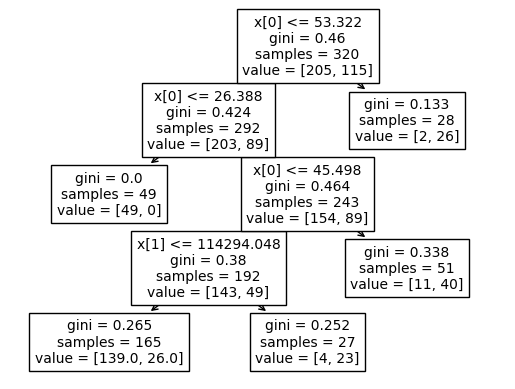

In [39]:
plot_tree(clf)

In [40]:
from sklearn.model_selection import cross_val_score

In [50]:
clf2 = DecisionTreeClassifier(criterion="gini", splitter="best", max_depth=4, min_samples_split=100, max_features=2, max_leaf_nodes=5, min_impurity_decrease=0.01)

In [51]:
clf2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_features=2, max_leaf_nodes=5,
                       min_impurity_decrease=0.01, min_samples_split=100)

In [53]:
y_pred = clf2.predict(X_test)

In [54]:
print("Acciracy Score: ", accuracy_score(y_test, y_pred))

Acciracy Score:  0.9125


In [57]:
np.mean(cross_val_score(clf2, X, y, cv=100))

0.835